Read rfi_and_ripple_para.md first.

author: Xu Chen, 2021.07

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/')
from util import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
from glob import glob
subname = '/data/inspur_disk04/FAST/liangtiantian/home/M31_v1/drift12/data/M31_Halo_Drift_12_arcdrift-M15_F-20200210-specs_T-bld.hdf5'
sub2 = h5py.File(subname,'r')
freq = sub2['freq'][:]

In [3]:
T = get_data(sub2,polar='average')
T_ori = deepcopy(T)

# time RFI

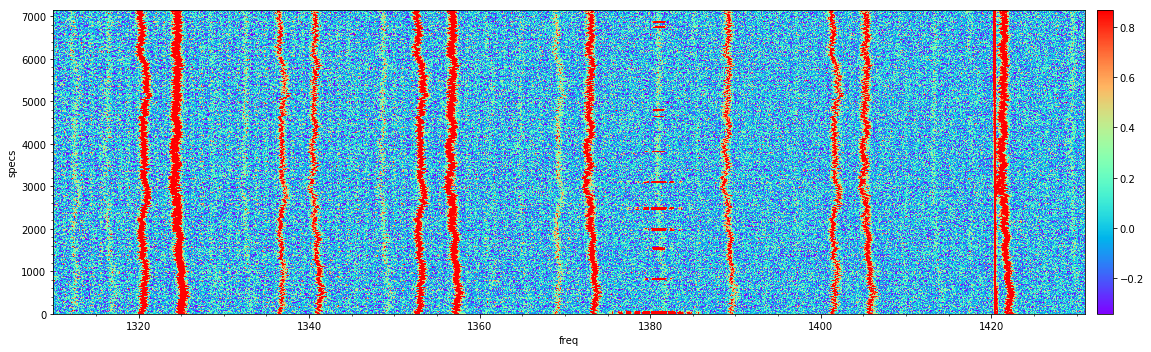

In [4]:
plot_waterfall(sub2,data = T,per_vmin_max=.90,figsize=(18,5))

In [5]:
from markRFI import mask_time_rfi#,get_startend

* --time_rfi：标记时域上突然出现的RFI，根据占据的频率长度，分为short-freq/long-freq。对该频率区间内的所有谱线做频率方向的平均后，画出一维的图。

* --sf
* --sf_frange: 一个典型的1～2MHz宽时域RFI，经常出现在1380～1382MHz。
* --sf_file: 或者可以指定一个二维数组的npy文件路径，在里面循环找，例如以下是只找时域RFI:
* --sf_times: 大于各谱线之中，中值的10倍，初步认为异常
* --sf_thr: 边缘处与附近值的差是中值的倍数，找出时间方向的边缘处陡峭的。但是现在8MHz RFI影响，边缘模糊，所以此数据暂时设为0.
* --sf_rfi_last: 持续出现的谱线数(对应函数的rfi_width_lim)
* --sf_T_thr: 选定区域后，大于温度阈值的被标记
* --sf_ext: 选定区域后，扩展边缘

INFO: Looking for short-freq time RFI in [1371, 1391] ... [markRFI]
Found :D
Finish


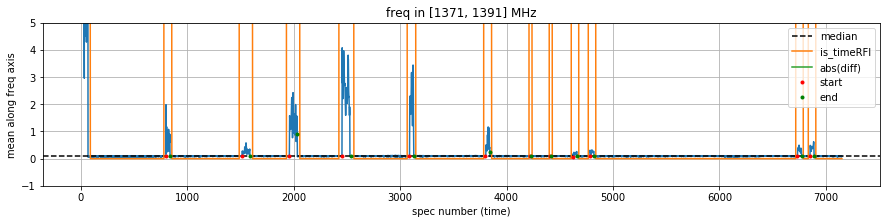

In [6]:
s_rfi = mask_time_rfi(T,freq,T_thr = .3, rtype = 'short-freq',frange =[1371,1391],times = 1,thr = 0,
                      ext_add=5,rfi_width_lim =10,plot = True,ylim=[-1,5])

* --lf
* --lf_beams: 已知出现大卫星干扰的波束，其他不搜寻。如果不设置就对所有波束搜寻。
* --lf_frange: 大范围频率
* --lf_times: 大于各谱线之中，中值1.5倍，初步认为异常.
* --lf_thr: 不需要边缘陡峭，所以设为0
* --lf_rfi_last: 持续出现的谱线数(对应函数的rfi_width_lim)
* --lf_ext: 选定区域后，扩展边缘

In [22]:
l_rfi = mask_time_rfi(T,freq, rtype = 'long-freq',frange =[1400,1500],times = 1.5,thr = 0,
                      ext_add=10,rfi_width_lim =50,plot = True)

INFO: Looking for long-freq time RFI ... [markRFI]
No long-freq time rfi is found.


In [7]:
T = deepcopy(T_ori)
T[s_rfi] = np.nan

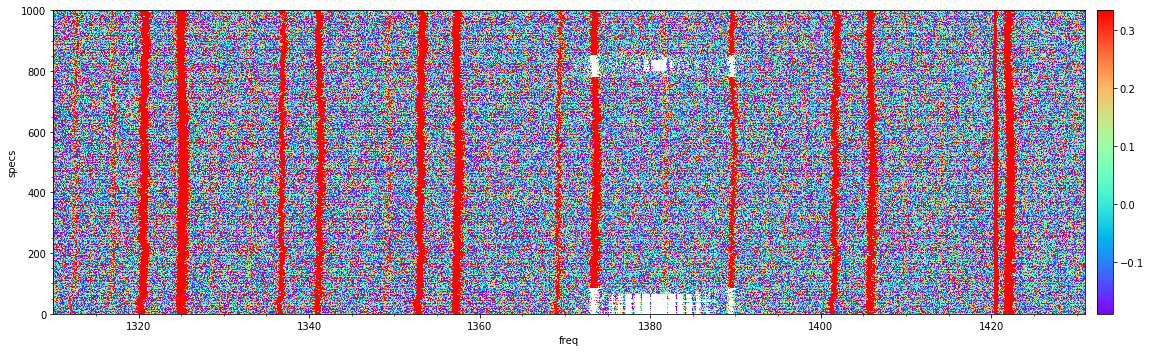

In [9]:
plot_waterfall(sub2,data = T[0:1000,:],per_vmin_max=.70,figsize=(18,5))

In [10]:
T = deepcopy(T_ori)
T[s_rfi] = 0

In [11]:
from markRFI import find_RFI,find_center,real_rms

# smooth

In [12]:
s_method_freq='gaussian' 
s_sigma_freq =3 
#s_method_t ='boxcar' 
#s_sigma_t = 3
from hifast.utils.misc import smooth1d
#if  s_method_t in ['gaussian', 'boxcar', 'median']:
#    T = smooth1d(T,axis = 0,sigma = s_sigma_t, method = s_method_t)

if  s_method_freq in ['gaussian', 'boxcar', 'median']:
    T = smooth1d(T,axis = 1,sigma = s_sigma_freq, method = s_method_freq)

# find period RFI

* --period_rfi: 标记频率上周期变化的RFI

* --rfi_thr: 大于rms rfi_thr倍的会被记为rfi
* --rms_frange: 用于计算rms的干净频率区间
* --rms_sigma: 如果区间有干扰，还是用该频率减去一个高斯平滑，得到准确的rms。此为高斯滤波的sigma。
* --mw_frange: 一个大致可能存在信号的区间，先保护起来，后面不会用它预估rfi位置

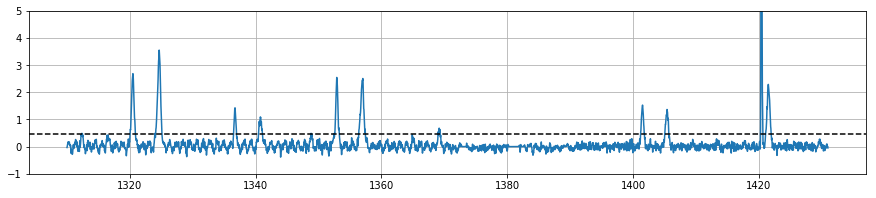

In [17]:
tn = 2000
spec = deepcopy(T[tn,:])
freq = sub2['freq'][:]
#--rms_frange，--rms_sigma
RMS = real_rms(spec,freq,sigma=6,rms_vrange=[1390,1400])

thr = 10*RMS #rfi_thr = 10

plt.figure(figsize=(15,3))
plt.plot(freq,spec)
plt.axhline(thr,linestyle = '--',color = 'k')
plt.grid()
plt.ylim(-1,5)

mw_range = [1419,1425]
protect_use = (freq>mw_range[0])&(freq<mw_range[1])
is_rfi = (spec>thr)&(~protect_use)
is_rfi_mw = (spec>thr)

* --rfi_groups: rfi的形态呈现为8.1MHz间隔的几组，分类进行更精确的拟合。'two groups','three groups','all'
* --rfi_width_lim: 粗找rfi区域时，其宽度应该大于的通道数。太细的可能是驻波，可能是点源，排除
* --ext_sec: 粗找到rfi后，扩充边界的通道数
* --freq_thr: 对粗测的rfi中心分类时，可以偏离预计中心一段频率。
* --freq_step: 对粗测的rfi中心分类时，预计中心的间隔大约为8.1MHz。

In [18]:
fcenter1,fcenter2,fcenter3,fc0 = find_center(spec,freq,is_rfi,RMS,freq_step = 8.1,
                                            rfi_width_lim=20,ext_sec = 20,freq_thr = .3,check = False)

In [19]:
fcenter1,fcenter2,fcenter3

(array([1324.66506958, 1340.74783325, 1357.04421997, 1405.4145813 ]),
 array([1320.48416138, 1336.72714233, 1352.90145874, 1369.18258667,
        1401.51596069]),
 array([], dtype=float64))

(-1, 5)

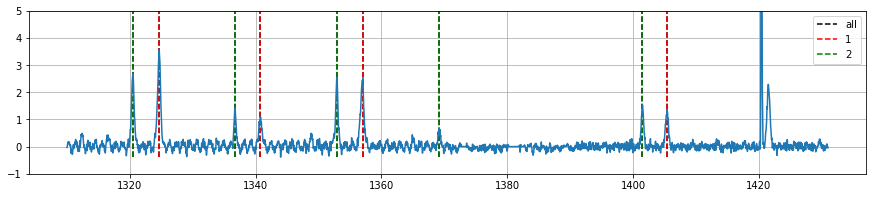

In [20]:
fig,ax = plt.subplots(figsize=(15,3))
ax.plot(freq,spec)
ymin = np.min(spec);ymax = np.max(spec)*.8
ax.vlines(fc0,ymin=ymin,ymax=ymax,linestyles='--',colors='k',label = 'all')
ax.vlines(fcenter1,ymin=ymin,ymax=ymax,linestyles='--',colors='r',label = '1')
ax.vlines(fcenter2,ymin=ymin,ymax=ymax,linestyles='--',colors='g',label = '2')
if fcenter3.size>0:
    ax.vlines(fcenter3,ymin=ymin,ymax=ymax,linestyles='--',colors='b',label = '3')
plt.grid();plt.legend();plt.ylim(-1,5)

## fixed freq mask all

* --ext_edge: 结果扩展边缘的通道数
* --mask_thr: 只mask超过rms的几倍。很小的rfi会保留。
* --mask_RFI_method: 'fixed freq' 对于小rfi，固定mask宽度
* --mask_all_theory: 是否理论的全mask，会非常干净(输出文件名含strict)
  --freq_from_theory: 很小的去掉多少频率(固定宽度)

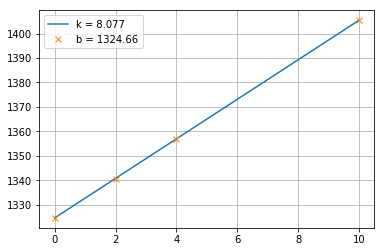

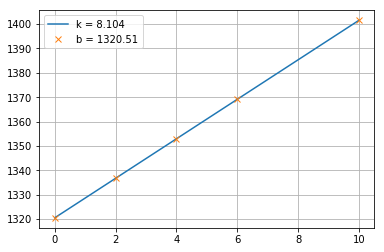

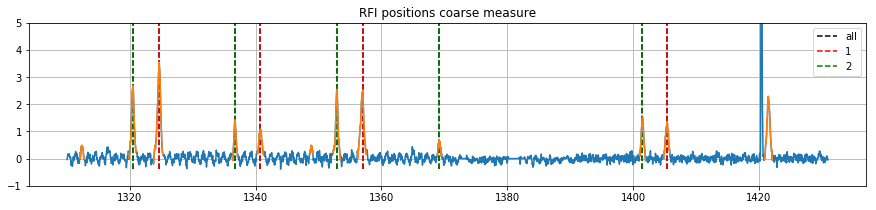

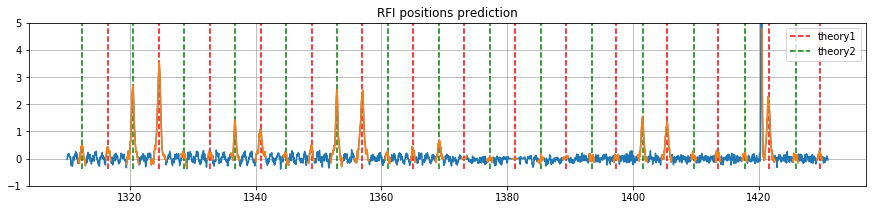

In [21]:
pd_rfi,theorys = find_RFI(spec,freq,is_rfi,is_rfi_mw ,ext_edge=5,plot =True,ylim=(-1,5),
                  rfi_width_lim=20,ext_sec = 20,RMS=RMS,rfi_fit_use='three groups',freq_thr = .3,mask_thr=7,
                       freq_from_theory=.5,mask_RFI_method ='fixed freq',mask_all_theory=True,
                          ret_type='theory 123')

## fixed freq, mask > mask_thr * rms

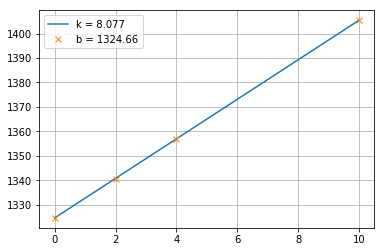

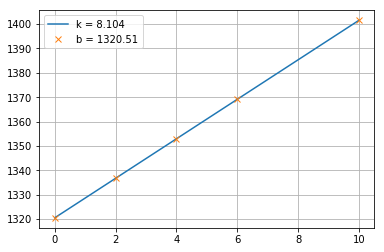

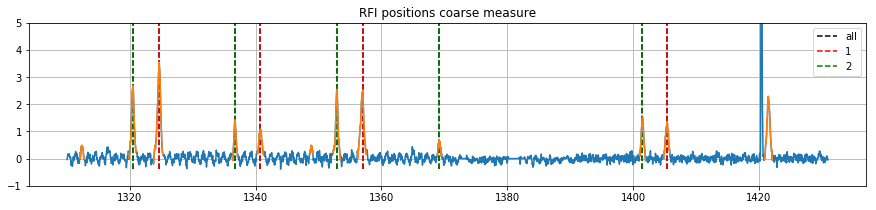

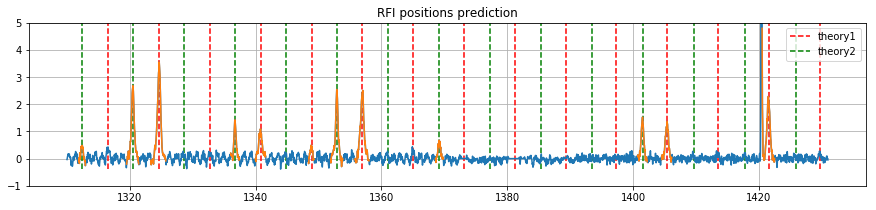

In [23]:
pd_rfi,theorys = find_RFI(spec,freq,is_rfi,is_rfi_mw ,ext_edge=5,plot =True,ylim=(-1,5),
                  rfi_width_lim=20,ext_sec = 20,RMS=RMS,rfi_fit_use='three groups',freq_thr = .3,mask_thr=7,
                       freq_from_theory=.5,mask_RFI_method ='fixed freq',
                          ret_type='theory 123')

## from center to two sides, mask > mask_thr * rms

* --mask_RFI_method: '2 sides' 从中心向两边按step循环，确定mask边界，比较慢
* --small_rfi_times: 小于RMS这个倍数的不标记
  --chan_step: step通道数
  --freq_from_theory: mask rfi最大的宽度

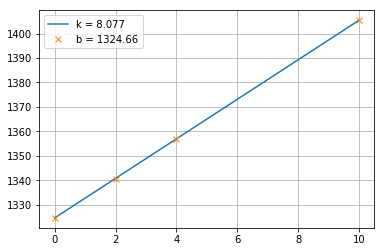

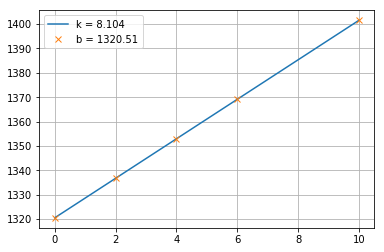

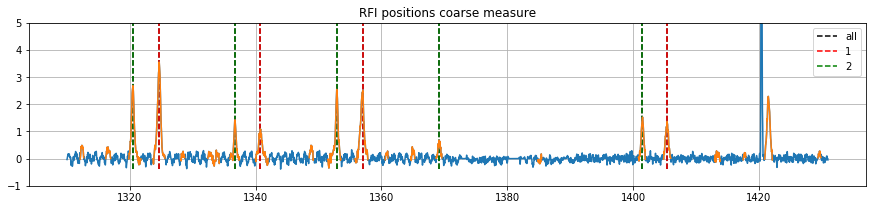

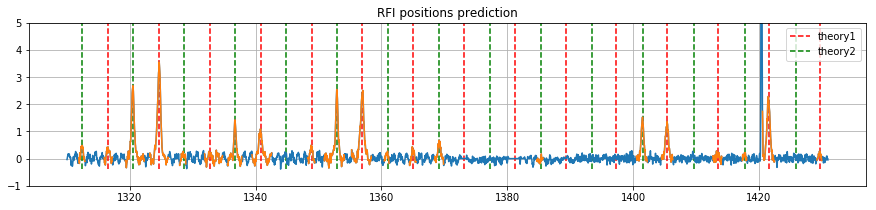

In [24]:
pd_rfi,theorys = find_RFI(spec,freq,is_rfi,is_rfi_mw ,ext_edge=5,plot =True,ylim=(-1,5),
                  rfi_width_lim=20,ext_sec = 20,RMS=RMS,rfi_fit_use='three groups',freq_thr = .3,mask_thr=7,
                mask_RFI_method ='2 sides',freq_from_theory=3,small_rfi_times=2,chan_step = 5)